In [2]:
!pip -q install datasketch statsmodels pytest
from google.colab import drive, userdata
drive.mount("/content/drive")
import sys; sys.path.insert(0, "/content/drive/MyDrive/spectra")
from spectra.common import *
from spectra.data import *
import zipfile, glob
import pandas as pd, numpy as np, matplotlib.pyplot as plt
setup_dirs(); seed_all()

with zipfile.ZipFile(RAW / "sir.zip") as z:
    z.extractall(RAW / "unzipped")
f = [p for p in glob.glob(str(RAW / "unzipped" / "**" / "*"), recursive=True) if p.lower().endswith(".csv")][0]
try:
    raw = pd.read_csv(f, low_memory=False)
except UnicodeDecodeError:
    raw = pd.read_csv(f, low_memory=False, encoding="latin-1")

df = add_fields(standardize(raw))
seen = set(df.loc[df.year <= 2022, "event_full"].dropna())
novel = df.groupby("year").event_full.apply(lambda s: float((~s.isin(seen)).mean()))
amp = df[df.amputation_bin == 1]
facts = {
    "source_file": Path(f).name, "raw_rows": len(raw), "raw_columns": list(raw.columns),
    "date_min": str(df.date.min()), "date_max": str(df.date.max()),
    "has_loss_of_eye_column": "loss_of_eye" in df.columns,
    "rows_per_year": df.year.value_counts().sort_index().to_dict(),
    "event_code_length_counts": df.event_full.str.len().value_counts().to_dict(),
    "narrative_words_median": float(df.n_words.median()),
    "share_novel_event_codes_by_year": novel.to_dict(),
    "amputation_rows_with_amputat_word": float(amp.narrative.str.contains(r"amputat", case=False).mean()),
}
save_json(facts, TABLES / "data_facts.json")
{k: v for k, v in facts.items() if k != "raw_columns"}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
saved /content/drive/MyDrive/spectra/results/tables/data_facts.json


{'source_file': 'January2015toNovember2025.csv',
 'raw_rows': 105996,
 'date_min': '2015-01-01 00:00:00',
 'date_max': '2025-11-30 00:00:00',
 'has_loss_of_eye_column': True,
 'rows_per_year': {2015: 9823,
  2016: 10084,
  2017: 10445,
  2018: 11156,
  2019: 11071,
  2020: 8915,
  2021: 8703,
  2022: 9110,
  2023: 8943,
  2024: 9034,
  2025: 8712},
 'event_code_length_counts': {4: 75276, 3: 28262, 2: 2458},
 'narrative_words_median': 31.0,
 'share_novel_event_codes_by_year': {2015: 0.0,
  2016: 0.0,
  2017: 0.0,
  2018: 0.0,
  2019: 0.0,
  2020: 0.0,
  2021: 0.0,
  2022: 0.0,
  2023: 0.00044727720004472774,
  2024: 0.6463360637591322,
  2025: 0.6336088154269972},
 'amputation_rows_with_amputat_word': 0.9577268338042273}

  dedupe 0/101227
  dedupe 20000/101227
  dedupe 40000/101227
  dedupe 60000/101227
  dedupe 80000/101227
  dedupe 100000/101227
raw 105996 -> filtered 101232 -> exact-dedup 101227 -> near-dedup 101227
saved /content/drive/MyDrive/spectra_work/data/label_map.json
saved /content/drive/MyDrive/spectra/results/tables/data_stats.json
saved results/tables/class_distribution.csv
19 classes: {'11': 'e.g. Hitting, kicking, beating, shoving', '13': 'e.g. Other animal bites, nonvenomous', '24': 'e.g. Pedestrian struck by vehicle in nonroadway area, unspecified', '27': 'e.g. Part of occupant s body caught between vehicle and other object in nonroadway transport incident', '31': 'e.g. Ignition of vapors, gases, or liquids', '32': 'e.g. Explosion of pressure vessel, piping, or tire', '40': 'Fall, slip, trip, unspecified ', '42': ' Slip, trip, stumble while stepping between levels', '43': 'e.g. Other fall to lower level, unspecified', '51': 'e.g. Direct exposure to electricity, unspecified', '53': '

{'rows': {'train': 40000, 'val': 5000, 'test': 8762, 'shift': 17527},
 'train_full_rows': 66151,
 'val_full_rows': 8787,
 'n_classes': 19,
 'pipeline_counts': {'raw': 105996,
  'filtered': 101232,
  'exact_dedup': 101227,
  'near_dedup': 101227},
 'amputation_prevalence': {'train': 0.269975,
  'val': 0.2686,
  'test': 0.2711709655329833,
  'shift': 0.2597135847549495},
 'shift_rows_mapped_to_other': 9300}

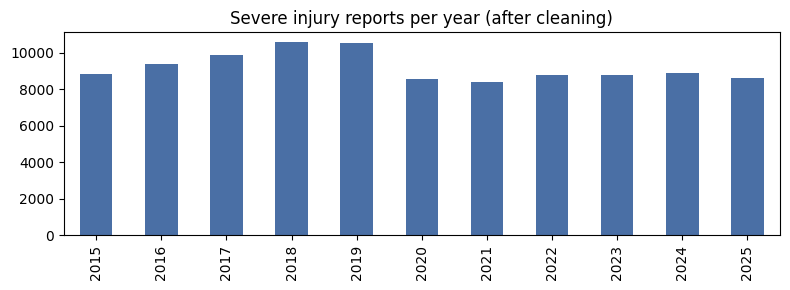

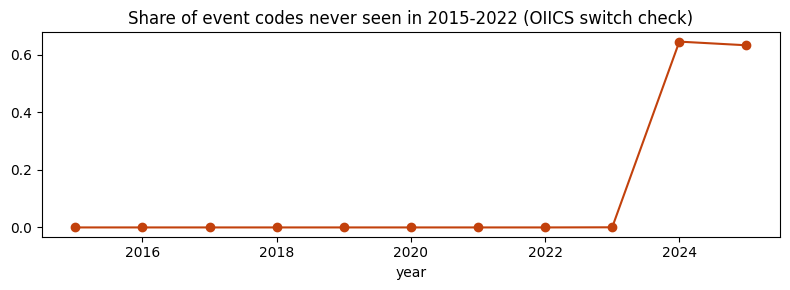

In [3]:
n_raw = len(df)
df = df[df.year.notna() & (df.n_words >= CFG["min_words"]) & df.event2.notna()].copy()
n_filtered = len(df)
df = df.sort_values("date").reset_index(drop=True)
df["norm"] = df.narrative.map(norm_text)
df = df.drop_duplicates("norm", keep="first").reset_index(drop=True)
n_exact = len(df)
df = df[near_dup_keep(df.narrative.tolist(), threshold=0.9)].reset_index(drop=True)
print(f"raw {n_raw} -> filtered {n_filtered} -> exact-dedup {n_exact} -> near-dedup {len(df)}")

df["narrative_masked"] = df.narrative.map(mask_text)
df["split"] = df.year.map(year_to_split)
train_full = df[df.split == "train"]
train = train_full.sample(n=min(CFG["train_sample"], len(train_full)), random_state=SEED).copy()
val_all = df[df.split == "val"]
val = val_all.sample(n=min(CFG["val_sample"], len(val_all)), random_state=SEED).copy()
test, shift = df[df.split == "test"].copy(), df[df.split == "shift"].copy()

counts = train.event2.value_counts()
keep_classes = sorted(counts[counts >= CFG["min_class_count"]].index)
classes = keep_classes + ["other"]; cid = {c: i for i, c in enumerate(classes)}
for d in (train, val, test, shift):
    d["y_event"] = d.event2.where(d.event2.isin(keep_classes), "other")
    d["label_id"] = d.y_event.map(cid).astype(int)

titles = {}
for c in keep_classes:
    g = df[df.event2 == c]; exact = g[g.event_full == c]
    titles[c] = exact.event_title.mode().iat[0] if len(exact) else "e.g. " + g.event_title.mode().iat[0]
titles["other"] = "Other (rare classes merged)"
unmapped_shift = shift.loc[~shift.event2.isin(keep_classes), "event2"].value_counts().to_dict()
save_json({"classes": classes, "titles": titles, "unmapped_shift_codes": unmapped_shift}, DATA / "label_map.json")

COLS = ["id", "date", "year", "split", "narrative", "narrative_masked", "event_full", "event2",
        "event_title", "y_event", "label_id", "amputation_bin", "hospitalized_bin", "loss_of_eye_bin",
        "nature_title", "part_title", "source_title", "naics", "sector", "state", "n_words"]
splits = dict(train=train, val=val, test=test, shift=shift)
for name, d in splits.items():
    d[[c for c in COLS if c in d.columns]].reset_index(drop=True).to_parquet(DATA / f"{name}.parquet", index=False)

stats = {
    "rows": {k: len(v) for k, v in splits.items()},
    "train_full_rows": len(train_full), "val_full_rows": len(val_all), "n_classes": len(classes),
    "pipeline_counts": dict(raw=n_raw, filtered=n_filtered, exact_dedup=n_exact, near_dedup=len(df)),
    "amputation_prevalence": {k: float(v.amputation_bin.mean()) for k, v in splits.items()},
    "shift_rows_mapped_to_other": int(sum(unmapped_shift.values())),
}
save_json(stats, TABLES / "data_stats.json")
save_table(pd.DataFrame({"class": classes, "title": [titles[c] for c in classes],
                         **{k: [int((v.y_event == c).sum()) for c in classes] for k, v in splits.items()}}),
           "class_distribution")

fig, ax = plt.subplots(figsize=(8, 3))
df.year.value_counts().sort_index().plot.bar(ax=ax, color="#4a6fa5")
ax.set_title("Severe injury reports per year (after cleaning)"); ax.set_xlabel(""); fig.tight_layout()
fig.savefig(FIGS / "rows_per_year.png", dpi=150)
fig, ax = plt.subplots(figsize=(8, 3))
novel.plot(marker="o", ax=ax, color="#c2410c")
ax.set_title("Share of event codes never seen in 2015-2022 (OIICS switch check)"); fig.tight_layout()
fig.savefig(FIGS / "oiics_switch_check.png", dpi=150)

print(len(classes), "classes:", {c: titles[c] for c in classes})
stats

In [4]:
pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 60)
# 1) near-dedupe sanity: an exact copy with one extra word should be dropped
t0, t1 = df.narrative.iloc[0], df.narrative.iloc[1]
print("dedupe check (want [True, False, True]):", near_dup_keep([t0, t0 + " today", t1]).tolist())

# 2) how 2-digit codes changed after the OIICS switch
pre, post = df[df.split != "shift"], df[df.split == "shift"]
mode = lambda x: x.mode().iat[0] if len(x.mode()) else ""
tab = pd.DataFrame({"pre_share": pre.event2.value_counts(normalize=True),
                    "post_share": post.event2.value_counts(normalize=True)}).fillna(0).round(3)
tab["pre_title"] = pre.groupby("event2").event_title.agg(mode)
tab["post_title"] = post.groupby("event2").event_title.agg(mode)
tab["in_classes"] = tab.index.isin(classes)
print(tab.sort_values("post_share", ascending=False).head(25))

# 3) 1-digit division (falls=4, contact=6, ...) before vs after
div = pd.DataFrame({"pre": pre.event2.str[0].value_counts(normalize=True),
                    "post": post.event2.str[0].value_counts(normalize=True)}).round(3)
print(div)

  dedupe 0/3
dedupe check (want [True, False, True]): [True, False, True]
        pre_share  post_share                                                    pre_title                                                   post_title  in_classes
event2                                                                                                                                                             
65          0.003       0.229  Struck, caught, or crushed in other collapsing structure...   Struck by running powered equipment  during maintenance...       False
41          0.003       0.178                               Slip on substance without fall                       Other fall to lower level  unspecified       False
43          0.172       0.140                       Other fall to lower level, unspecified                       Fall on same level due to slip or trip        True
64          0.249       0.123  Caught in running equipment or machinery during regular ...                

In [5]:
DIV_TITLES = {"1": "Violence and other injuries by persons or animals", "2": "Transportation incidents",
              "3": "Fires and explosions", "4": "Falls, slips, trips",
              "5": "Exposure to harmful substances or environments", "6": "Contact with objects and equipment",
              "7": "Overexertion and bodily reaction", "9": "Nonclassifiable"}
divs = sorted(DIV_TITLES); did = {d: i for i, d in enumerate(divs)}
for name in ["train", "val", "test", "shift"]:
    p = DATA / f"{name}.parquet"; x = pd.read_parquet(p)
    x["y_div"] = x.event2.str[0]; x["div_id"] = x.y_div.map(did).astype(int)
    x.to_parquet(p, index=False)
    print(name, x.y_div.value_counts().sort_index().to_dict())

lm = load_json(DATA / "label_map.json")
lm.update(divisions=divs, div_titles=DIV_TITLES,
          class_div={c: (c[0] if c != "other" else None) for c in lm["classes"]},
          note="OIICS 3 (2024+) renumbered 2-digit codes; shift split is scored at division (1-digit) level.")
save_json(lm, DATA / "label_map.json")

save_table(tab.reset_index(), "oiics_code_meaning_shift")
save_table(div.reset_index(names="division"), "division_shares")

with open(REPO / "tests" / "test_data.py", "a") as fh:
    fh.write('''
def test_division_labels(d):
    for s in SPLITS:
        assert d[s].div_id.notna().all() and d[s].y_div.isin(list("12345679")).all(), s
''')
print("division labels added")

train {'1': 868, '2': 3518, '3': 717, '4': 12016, '5': 3112, '6': 18944, '7': 591, '9': 234}
val {'1': 129, '2': 511, '3': 89, '4': 1543, '5': 384, '6': 2241, '7': 72, '9': 31}
test {'1': 211, '2': 822, '3': 162, '4': 2717, '5': 714, '6': 3994, '7': 105, '9': 37}
shift {'1': 212, '2': 1637, '3': 321, '4': 5753, '5': 1399, '6': 7937, '7': 236, '9': 32}
saved /content/drive/MyDrive/spectra_work/data/label_map.json
saved results/tables/oiics_code_meaning_shift.csv
saved results/tables/division_shares.csv
division labels added


In [6]:
!cd /content/drive/MyDrive/spectra && python -m pytest -q tests
commit("Data: clean, dedupe, mask, time splits, division labels for OIICS-3 shift, EDA, tests")

........ss.                                                              [100%]
9 passed, 2 skipped in 5.70s
90b4e65 Data: clean, dedupe, mask, time splits, division labels for OIICS-3 shift, EDA, tests
1e6aa82 Add notebook 00_setup.ipynb
85dcbcc Project scaffold: config, helpers, tests, licence
